<a href="https://colab.research.google.com/github/fronre/Big_Data_Intero/blob/main/Total_Response_Size_per_Status.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 MapReduce Response Size Analysis

This task applies the MapReduce model to analyze the total response size for each HTTP status code in web server logs.

🎯 Goal:
To compute the total amount of data (in bytes) returned by the server for each status code.

🚀 Insight:
By measuring the total response size, we can evaluate bandwidth usage and understand how different types of responses impact system performance.

👉 This demonstrates how MapReduce can be used not only for counting requests but also for aggregating quantitative metrics such as data size.

In [1]:
%%writefile weblogs.txt
# Date, Time, IP, Method, URL, Status, ResponseSize
2026-04-28,12:01:32,192.168.1.2,GET,/index.html,200,1024
2026-04-28,12:01:33,192.168.1.3,GET,/products.html,200,850
2026-04-28,12:01:35,192.168.1.4,GET,/contact.html,404,512
2026-04-28,12:01:38,192.168.1.5,POST,/checkout,500,128
2026-04-28,12:01:41,192.168.1.6,GET,/index.html,200,1024
2026-04-28,12:01:45,192.168.1.7,GET,/images/logo.png,200,256
2026-04-28,12:01:48,192.168.1.8,GET,/about.html,404,512
2026-04-28,12:01:53,192.168.1.9,POST,/login,403,64
2026-04-28,12:02:01,192.168.1.10,GET,/index.html,200,1024
2026-04-28,12:02:07,192.168.1.11,POST,/checkout,500,128
2026-04-28,12:02:12,192.168.1.12,GET,/contact.html,404,512
2026-04-28,12:02:15,192.168.1.13,GET,/index.html,200,1024
2026-04-28,12:02:21,192.168.1.14,GET,/products.html,200,850
2026-04-28,12:02:23,192.168.1.15,GET,/about.html,404,512
2026-04-28,12:02:29,192.168.1.16,POST,/checkout,500,128
2026-04-28,12:02:31,192.168.1.17,GET,/images/logo.png,200,256
2026-04-28,12:02:34,192.168.1.18,GET,/contact.html,404,512
2026-04-28,12:02:38,192.168.1.19,POST,/login,403,64
2026-04-28,12:02:41,192.168.1.20,GET,/index.html,200,1024
2026-04-28,12:02:47,192.168.1.21,GET,/products.html,200,850

Writing weblogs.txt


# **Implement the Mapper**

In [2]:
def mapper(line):
    fields = line.strip().split(",")

    if len(fields) != 7 or fields[0].startswith('#'):
        return []

    status = fields[5]
    size = int(fields[6])

    return [(status, size)]

# **Shuffle Phase**

In [3]:
from collections import defaultdict

def shuffle(mapped_data):
    grouped = defaultdict(list)
    for key, value in mapped_data:
        grouped[key].append(value)
    return grouped

# **Reducer Phase**

In [4]:
def reducer(grouped_data):
    result = {}
    for key, values in grouped_data.items():
        result[key] = sum(values)
    return result

# Combine the **Phases**

In [5]:
mapped = []

with open("weblogs.txt", "r") as f:
    for line in f:
        mapped.extend(mapper(line))

grouped = shuffle(mapped)
reduced = reducer(grouped)

print("=== Total Response Size per Status ===")

for status, total_size in sorted(reduced.items()):
    print(f"HTTP {status}: total size = {total_size}")

=== Total Response Size per Status ===
HTTP 200: total size = 8182
HTTP 403: total size = 128
HTTP 404: total size = 2560
HTTP 500: total size = 384


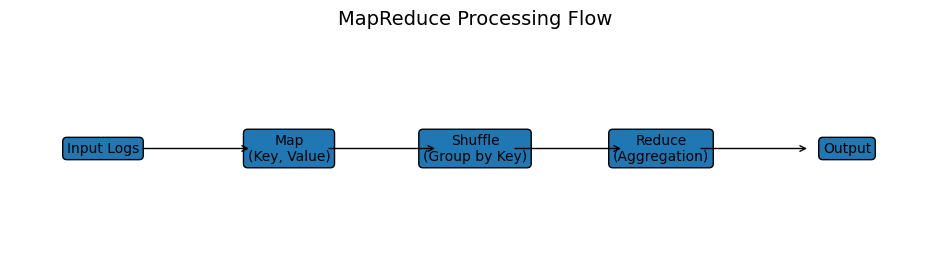

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12,3))

steps = [
    "Input Logs",
    "Map\n(Key, Value)",
    "Shuffle\n(Group by Key)",
    "Reduce\n(Aggregation)",
    "Output"
]

# رسم النصوص
for i in range(len(steps)):
    ax.text(i, 0, steps[i], ha='center', va='center', fontsize=10, bbox=dict(boxstyle="round", pad=0.3))

# رسم الأسهم
for i in range(len(steps)-1):
    ax.annotate("",
                xy=(i+0.8, 0),
                xytext=(i+0.2, 0),
                arrowprops=dict(arrowstyle="->"))

ax.set_xlim(-0.5, len(steps)-0.5)
ax.set_ylim(-1, 1)
ax.axis('off')

plt.title("MapReduce Processing Flow", fontsize=14)
plt.show()